In [14]:
import pandas as pd
import numpy as np

df=pd.read_csv('../original_datasets/customers.csv')

print(df.info())
print(df.describe())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 5120 entries, 0 to 5119
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customer_id       5120 non-null   str  
 1   customer_name     5077 non-null   str  
 2   email             5033 non-null   str  
 3   phone             5012 non-null   str  
 4   city              5120 non-null   str  
 5   state             5120 non-null   str  
 6   pincode           5120 non-null   int64
 7   signup_date       5120 non-null   str  
 8   customer_segment  5120 non-null   str  
 9   is_prime_member   5120 non-null   str  
 10  lifetime_orders   5065 non-null   str  
 11  avg_rating_given  4941 non-null   str  
dtypes: int64(1), str(11)
memory usage: 480.1 KB
None
             pincode
count    5120.000000
mean   475741.495312
std    202854.487115
min    110001.000000
25%    380001.000000
50%    530001.000000
75%    625001.000000
max    781001.000000
  customer_id      customer_nam

In [15]:
print(df['signup_date'])

0       2021-08-12 00:00:00
1          25/07/2023 00:00
2                10-03-2023
3       2023-08-04 00:00:00
4                29-07-2023
               ...         
5115       29/08/2023 00:00
5116       16/09/2022 00:00
5117    2023-01-30 00:00:00
5118             18-05-2022
5119             19-08-2021
Name: signup_date, Length: 5120, dtype: str


In [16]:
print(df.duplicated().sum())

120


In [17]:
df=df.drop_duplicates()

In [18]:
print(df.isna().sum())

customer_id           0
customer_name        43
email                86
phone               106
city                  0
state                 0
pincode               0
signup_date           0
customer_segment      0
is_prime_member       0
lifetime_orders      54
avg_rating_given    175
dtype: int64


In [21]:
# Define placeholder values commonly found in dirty datasets
placeholder_vals = ['', 'nan', 'NaN', '-', 'unknown', 'NA', 'N/A', '   ']

# 2. Clean email first
df['email'] = df['email'].astype(str).str.strip().str.lower()
df.loc[df['email'].isin(placeholder_vals + ['null', 'na', 'n/a']), 'email'] = np.nan

# 3. Clean customer_name and infer from email if missing/blank
df['customer_name'] = df['customer_name'].astype(str).str.strip()
df.loc[df['customer_name'].isin(placeholder_vals), 'customer_name'] = np.nan

def derive_name_from_email(row):
    if pd.isna(row['customer_name']) and pd.notna(row['email']):
        local_part = row['email'].split('@')[0]
        import re
        cleaned_name = re.sub(r'[\d_.]+', ' ', local_part).strip()
        return cleaned_name.title()
    return row['customer_name']

df['customer_name'] = df.apply(derive_name_from_email, axis=1)
df['customer_name'] = df['customer_name'].str.title()

# 4. Clean phone: strip spaces, convert placeholders to NaN
df['phone'] = df['phone'].astype(str).str.strip()
df.loc[df['phone'].isin(placeholder_vals + ['null', 'na', 'n/a']), 'phone'] = np.nan

# 5. Clean city and state formatting
df['city'] = df['city'].astype(str).str.strip().str.title()
df['state'] = df['state'].astype(str).str.strip().str.upper()

# 6. Clean and standardize signup_date (Removes timestamps and unifies to YYYY-MM-DD)
def parse_and_strip_timestamp(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).strip()
    if val_str in placeholder_vals + ['null', 'na', 'n/a']:
        return np.nan
    for fmt in ('%Y-%m-%d %H:%M:%S', '%Y-%m-%d', '%d/%m/%Y %H:%M', '%d/%m/%Y %H:%M:%S', '%d/%m/%Y', '%d-%m-%Y', '%d-%m-%Y %H:%M:%S'):
        try:
            dt = pd.to_datetime(val_str, format=fmt, errors='raise')
            return dt.strftime('%Y-%m-%d')  # Extracts date only, dropping timestamp
        except ValueError:
            continue
    dt = pd.to_datetime(val_str, errors='coerce')
    if not pd.isna(dt):
        return dt.strftime('%Y-%m-%d')
    return np.nan

df['signup_date'] = df['signup_date'].apply(parse_and_strip_timestamp)

# 7. Clean customer_segment: standardize capitalization/naming
df['customer_segment'] = df['customer_segment'].astype(str).str.strip().str.title()
df['customer_segment'] = df['customer_segment'].replace({'Business': 'Business', 'Smb': 'SMB'})

# 8. Clean is_prime_member: map diverse boolean representations to Yes/No
prime_mapping = {
    'yes': 'Yes', 'y': 'Yes', 'true': 'Yes', '1': 'Yes', '1.0': 'Yes',
    'no': 'No', 'n': 'No', 'false': 'No', '0': 'No', '0.0': 'No'
}
df['is_prime_member'] = df['is_prime_member'].astype(str).str.strip().str.lower()
df['is_prime_member'] = df['is_prime_member'].map(prime_mapping).fillna('No')

# 9. Clean numeric fields (lifetime_orders, avg_rating_given)
df['lifetime_orders'] = pd.to_numeric(df['lifetime_orders'], errors='coerce')
df['avg_rating_given'] = pd.to_numeric(df['avg_rating_given'], errors='coerce')

In [22]:
# Check string lengths of signup_date to see if there are varying formats
print(df['signup_date'].str.len().value_counts())

# View a random sample of 20 dates
print(df['signup_date'].sample(20, random_state=42).tolist())

signup_date
10    5000
Name: count, dtype: int64
['2021-09-21', '2021-07-24', '2023-12-05', '2022-05-13', '2021-12-08', '2021-10-27', '2023-10-18', '2022-01-15', '2021-09-10', '2023-02-23', '2022-05-16', '2023-02-27', '2023-12-07', '2023-05-10', '2022-06-01', '2023-01-09', '2023-12-10', '2023-02-27', '2022-07-07', '2023-12-01']


In [23]:
print(df.isna().sum())

customer_id           0
customer_name         6
email               162
phone               191
city                  0
state                 0
pincode               0
signup_date           0
customer_segment      0
is_prime_member       0
lifetime_orders      96
avg_rating_given    317
dtype: int64


In [25]:
# Replace the remaining missing or blank customer names with 'Unknown'
df['customer_name'] = df['customer_name'].fillna('Unknown')

# If any empty strings or placeholder strings slipped through, replace them as well
placeholder_vals = ['', 'nan', 'NaN', '-', 'unknown', 'NA', 'N/A', '   ']
df.loc[df['customer_name'].str.strip().isin(placeholder_vals), 'customer_name'] = 'Unknown'

# Save the updated file
df.to_csv('customers_cleaned.csv', index=False)
print("Remaining customer names filled with 'Unknown'.")

# 1. Fill missing email and phone with 'unknown'
df['email'] = df['email'].fillna('unknown')
df['phone'] = df['phone'].fillna('unknown')

# 2. Fill missing numeric columns (lifetime_orders and avg_rating_given) with their respective medians
df['lifetime_orders'] = df['lifetime_orders'].fillna(df['lifetime_orders'].median())
df['avg_rating_given'] = df['avg_rating_given'].fillna(df['avg_rating_given'].median())

# Verify that all missing values are now zero
print("Missing values after filling:")
print(df.isnull().sum())

Remaining customer names filled with 'Unknown'.
Missing values after filling:
customer_id         0
customer_name       0
email               0
phone               0
city                0
state               0
pincode             0
signup_date         0
customer_segment    0
is_prime_member     0
lifetime_orders     0
avg_rating_given    0
dtype: int64


C:\Users\VIDHYA\AppData\Local\Temp\ipykernel_2516\419818216.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='customer_segment', order=df['customer_segment'].value_counts().index, palette='viridis')


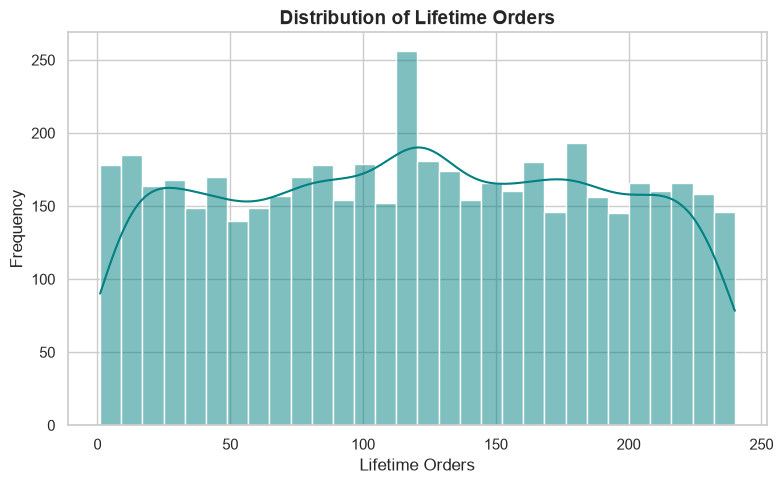

C:\Users\VIDHYA\AppData\Local\Temp\ipykernel_2516\419818216.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='avg_rating_given', palette='coolwarm')


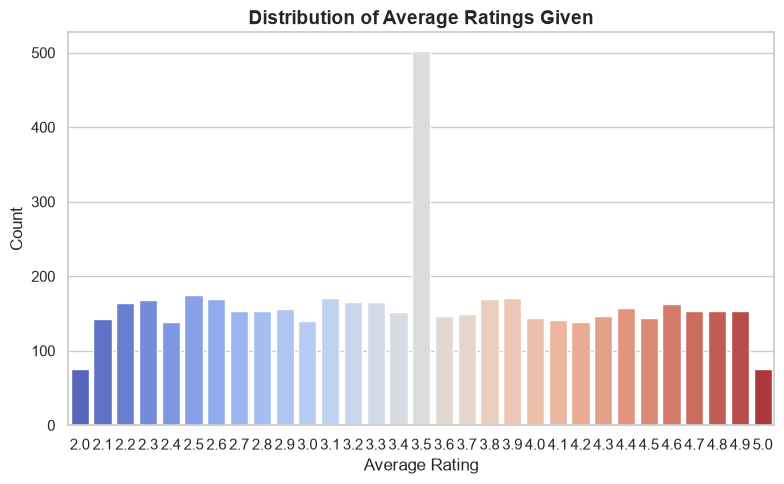

C:\Users\VIDHYA\AppData\Local\Temp\ipykernel_2516\419818216.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_states.index, y=top_states.values, palette='magma')


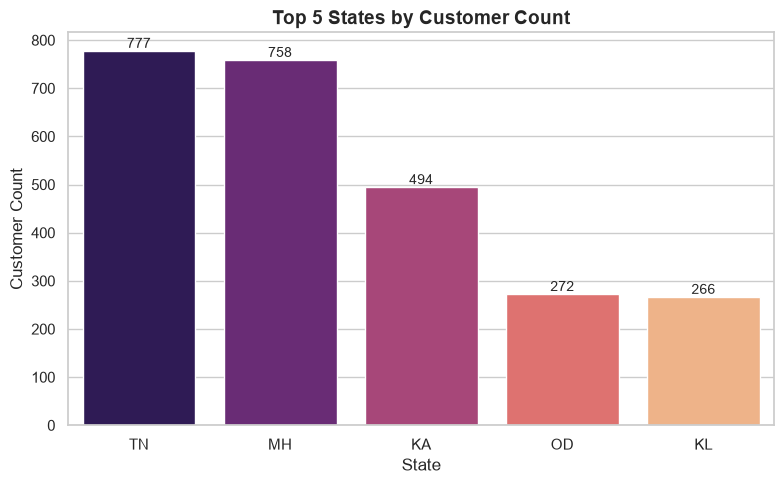

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

df = pd.read_csv('customers_cleaned.csv')

# 1. Customer Segment Distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='customer_segment', order=df['customer_segment'].value_counts().index, palette='viridis')
plt.title('Customer Count by Segment', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Count', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)
plt.tight_layout()
#plt.savefig('segment_distribution.png')
plt.close()

# 2. Lifetime Orders Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['lifetime_orders'], kde=True, color='teal', bins=30)
plt.title('Distribution of Lifetime Orders', fontsize=14, fontweight='bold')
plt.xlabel('Lifetime Orders', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# 3. Average Rating Given Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='avg_rating_given', palette='coolwarm')
plt.title('Distribution of Average Ratings Given', fontsize=14, fontweight='bold')
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

# 4. Top 5 States
plt.figure(figsize=(8, 5))
top_states = df['state'].value_counts().head(5)
ax = sns.barplot(x=top_states.index, y=top_states.values, palette='magma')
plt.title('Top 5 States by Customer Count', fontsize=14, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Customer Count', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)
plt.tight_layout()
plt.show()
plt.close()

In [27]:
def check_outliers(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    print(f"--- Outlier Analysis for {name} ---")
    print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
    print(f"Number of outliers: {len(outliers)} out of {len(series)}\n")

check_outliers(df['lifetime_orders'], 'lifetime_orders')
check_outliers(df['avg_rating_given'], 'avg_rating_given')

--- Outlier Analysis for lifetime_orders ---
Q1: 62.0, Q3: 178.0, IQR: 116.0
Lower Bound: -112.0, Upper Bound: 352.0
Number of outliers: 0 out of 5000

--- Outlier Analysis for avg_rating_given ---
Q1: 2.8, Q3: 4.2, IQR: 1.4000000000000004
Lower Bound: 0.6999999999999993, Upper Bound: 6.300000000000001
Number of outliers: 0 out of 5000

